<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/bike_rental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bike Sharing Demand Dataset generated successfully!
Dataset Shape: (2500, 9)
   Hour  Temp_C  Humidity  Windspeed  Season  WorkingDay  Is_Holiday  Weather  \
0     6    12.4      40.5       10.4       1           0           1        2   
1    19    36.6      54.1       35.0       1           1           0        1   
2    14    23.9      83.8       30.1       1           0           1        3   
3    10    35.8      62.4        0.7       1           1           0        2   
4     7    24.0      70.6       20.7       3           0           0        1   

   Rental_Count  
0           111  
1           240  
2           128  
3           193  
4           199  


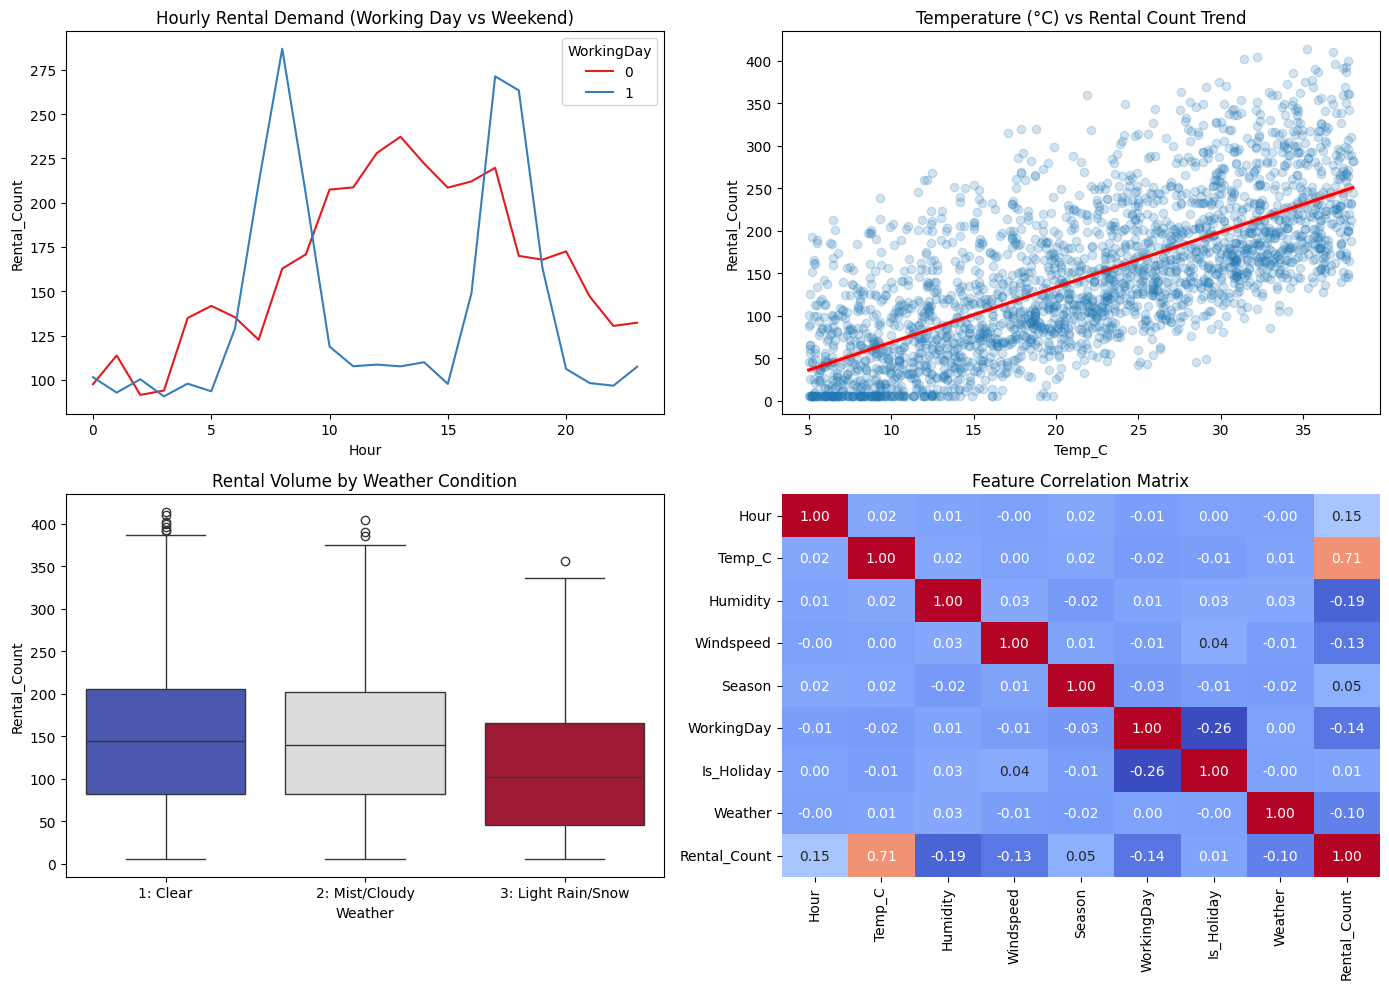

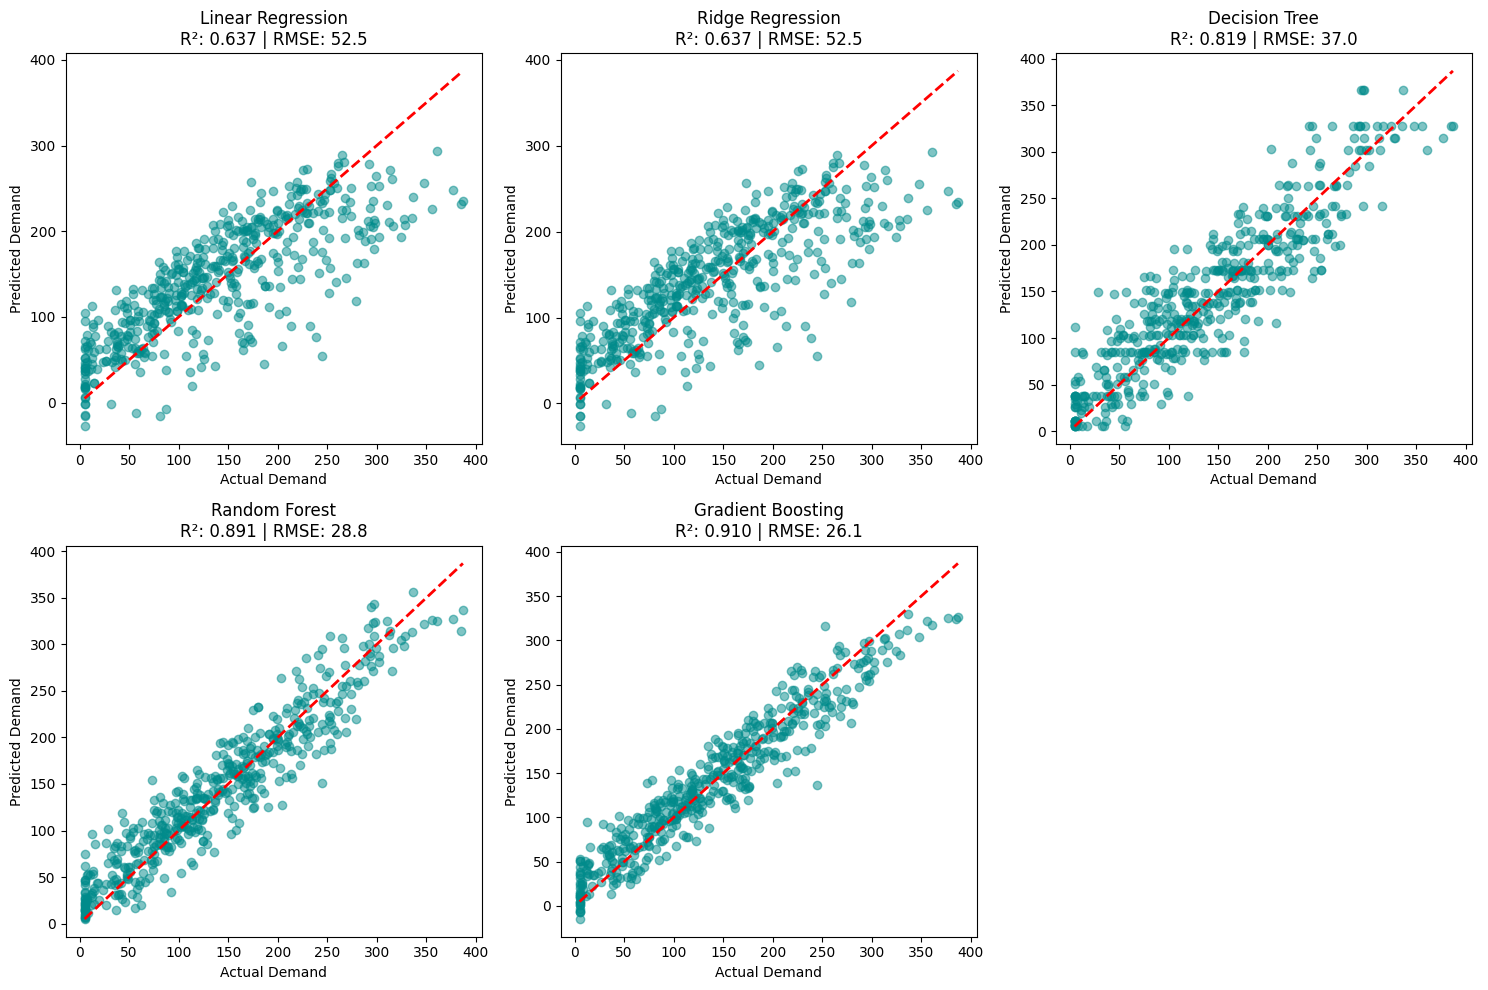

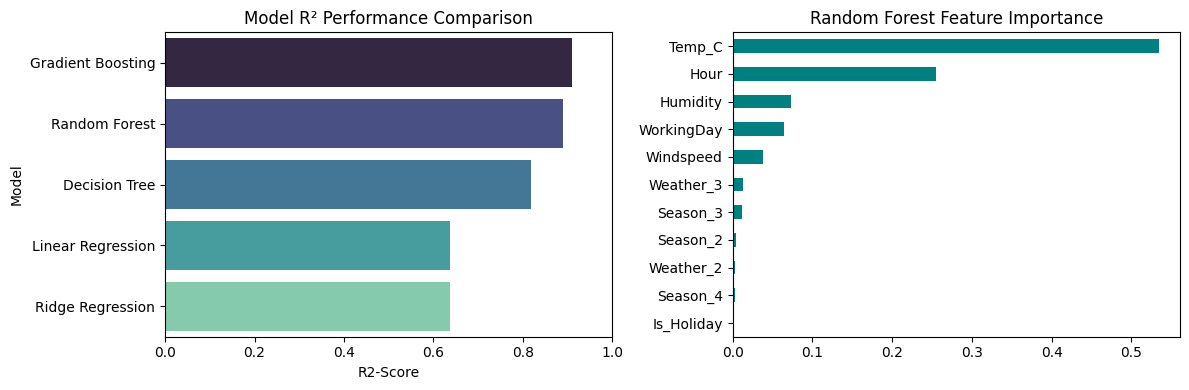


=== BIKE RENTAL DEMAND PREDICTION PERFORMANCE RANKING ===
            Model  R2-Score  MAE (Bikes)  RMSE (Bikes)
Gradient Boosting  0.909863    20.835404     26.125150
    Random Forest  0.890601    22.694140     28.781616
    Decision Tree  0.819090    29.041411     37.011693
Linear Regression  0.636689    41.165274     52.450201
 Ridge Regression  0.636533    41.197869     52.461463


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE REALISTIC BIKE SHARING DATASET
# ==========================================
np.random.seed(42)
n_samples = 2500

# Feature Generation
hour = np.random.randint(0, 24, n_samples)
temp = np.random.uniform(5.0, 38.0, n_samples).round(1)
humidity = np.random.uniform(15.0, 95.0, n_samples).round(1)
windspeed = np.random.uniform(0.0, 40.0, n_samples).round(1)
season = np.random.choice([1, 2, 3, 4], size=n_samples, p=[0.25, 0.25, 0.25, 0.25])  # 1:Spring, 2:Summer, 3:Fall, 4:Winter
workingday = np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7])
is_holiday = np.where(workingday == 1, 0, np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1]))
weather = np.random.choice([1, 2, 3], size=n_samples, p=[0.6, 0.3, 0.1])  # 1:Clear, 2:Mist/Cloudy, 3:Rain/Snow

# Domain logic: Commute hour peaks on working days (8 AM and 5-6 PM)
commute_peak = workingday * (np.exp(-0.5 * (hour - 8)**2) + np.exp(-0.5 * (hour - 17.5)**2)) * 180
weekend_peak = (1 - workingday) * (np.exp(-0.02 * (hour - 14)**2)) * 120

rental_count = (
    20.0
    + commute_peak
    + weekend_peak
    + 6.5 * temp
    - 0.8 * humidity
    - 0.9 * windspeed
    + 25.0 * (season == 3)   # Higher demand in Fall
    - 45.0 * (weather == 3)  # Rain/Snow significantly reduces demand
    + np.random.normal(0, 20, n_samples)
).clip(5, 950).round(0).astype(int)

df = pd.DataFrame({
    'Hour': hour,
    'Temp_C': temp,
    'Humidity': humidity,
    'Windspeed': windspeed,
    'Season': season,
    'WorkingDay': workingday,
    'Is_Holiday': is_holiday,
    'Weather': weather,
    'Rental_Count': rental_count
})

print("Bike Sharing Demand Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Hourly Demand Pattern by WorkingDay
plt.subplot(2, 2, 1)
sns.lineplot(x="Hour", y="Rental_Count", data=df, hue="WorkingDay", palette="Set1", errorbar=None)
plt.title("Hourly Rental Demand (Working Day vs Weekend)")

# Graph 2: Temperature vs Rental Count Trend
plt.subplot(2, 2, 2)
sns.regplot(x="Temp_C", y="Rental_Count", data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("Temperature (°C) vs Rental Count Trend")

# Graph 3: Weather Situation Impact on Rentals
plt.subplot(2, 2, 3)
sns.boxplot(x="Weather", y="Rental_Count", data=df, hue="Weather", palette="coolwarm", legend=False)
plt.xticks(ticks=[0, 1, 2], labels=['1: Clear', '2: Mist/Cloudy', '3: Light Rain/Snow'])
plt.title("Rental Volume by Weather Condition")

# Graph 4: Feature Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & FEATURE ENCODING
# ==========================================
X = df.drop(columns=["Rental_Count"])
y = df["Rental_Count"]

# One-hot encode categorical features ('Season', 'Weather')
X_encoded = pd.get_dummies(X, columns=['Season', 'Weather'], drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & REGRESSION EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2-Score": r2,
        "MAE (Bikes)": mae,
        "RMSE (Bikes)": rmse
    })

    # Plot Actual vs Predicted Rental Demand
    axes[idx].scatter(y_test, y_pred, alpha=0.5, color='darkcyan')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: {rmse:.1f}")
    axes[idx].set_xlabel("Actual Demand")
    axes[idx].set_ylabel("Predicted Demand")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: R2-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="R2-Score", y="Model", data=results_df, hue="Model", palette="mako", legend=False)
plt.title("Model R² Performance Comparison")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="teal")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== BIKE RENTAL DEMAND PREDICTION PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))
